# Forcasting Multiple Articles

📂 Please click 'Choose Files' to upload your BigQuery Master Extract:


Saving GitHub_Sample_Retail_Data.csv to GitHub_Sample_Retail_Data (1).csv
⚙️ Processing file: GitHub_Sample_Retail_Data (1).csv
📦 Found 3 unique articles to forecast.

--------------------------------------------------
🚀 Processing Article: 100001
📊 Mode: NEW LINE -> Dropping first 12 weeks of bad Store Count data.
🛠️ Valid history: 46 wks. LOCKING trend to flat and disabling seasonality.


/tmp/ipykernel_245/3972904884.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price'] = df['price'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_245/3972904884.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['discount_pcnt'] = df['discount_pcnt'].fillna(method='ffill').fillna(method='bfill')


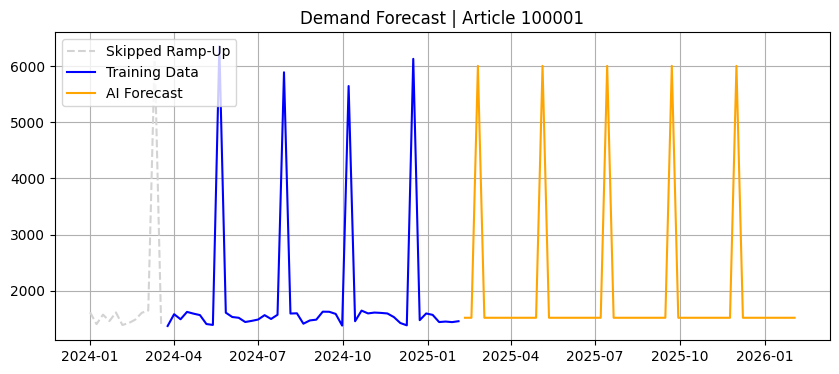

--------------------------------------------------
🚀 Processing Article: 100002
📊 Mode: NEW LINE -> Dropping first 12 weeks of bad Store Count data.
🛠️ Valid history: 46 wks. LOCKING trend to flat and disabling seasonality.


/tmp/ipykernel_245/3972904884.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price'] = df['price'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_245/3972904884.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['discount_pcnt'] = df['discount_pcnt'].fillna(method='ffill').fillna(method='bfill')


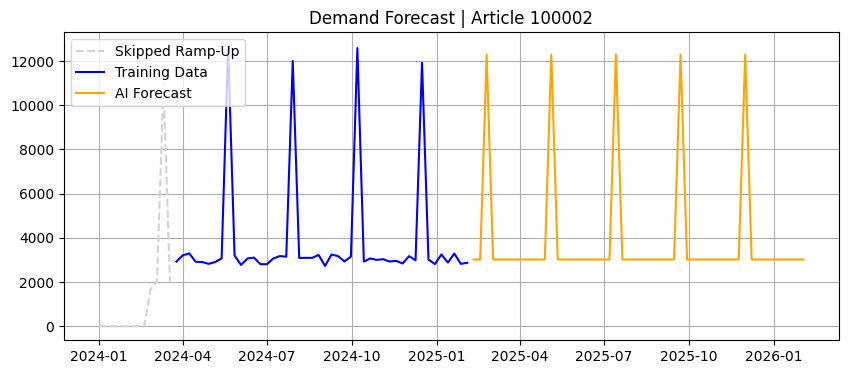

--------------------------------------------------
🚀 Processing Article: 100003
📊 Mode: NEW LINE -> Dropping first 12 weeks of bad Store Count data.
🛠️ Valid history: 46 wks. LOCKING trend to flat and disabling seasonality.


/tmp/ipykernel_245/3972904884.py:61: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['price'] = df['price'].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_245/3972904884.py:62: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['discount_pcnt'] = df['discount_pcnt'].fillna(method='ffill').fillna(method='bfill')


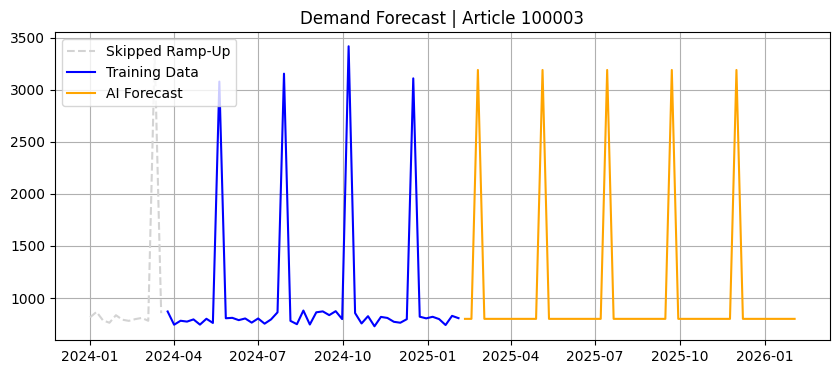

--------------------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ALL DONE! Successfully generated forecasts for 3 articles.
📥 Master file downloading as: Master_Forecast_Batch_GitHub_Sample_Retail_Data (1).csv


In [ ]:
# Install Prophet if needed
!pip install prophet

import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from google.colab import files
import io

# 1. Upload Data
print("📂 Please click 'Choose Files' to upload your BigQuery Master Extract:")
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"⚙️ Processing file: {filename}")

# Read the file
df_main = pd.read_csv(io.BytesIO(uploaded[filename]))
df_main['WeekStartDate'] = pd.to_datetime(df_main['WeekStartDate'])

# Find all unique articles in the file
unique_articles = df_main['article'].unique()
print(f"📦 Found {len(unique_articles)} unique articles to forecast.\n")

# This list will hold the finished forecasts for every item before stitching them together
all_forecasts = []

# =========================================================
# 🔄 START BATCH LOOP: Process each article one by one
# =========================================================
for article_id in unique_articles:
    try:
        print(f"--------------------------------------------------")
        print(f"🚀 Processing Article: {article_id}")

        # Isolate the data for just this one article
        df = df_main[df_main['article'] == article_id].copy()
        df = df.sort_values(by='WeekStartDate')

        # 2. Split History to safely isolate the bad data early
        full_history = df[df['ActDmd'].notnull()].copy()
        total_history_weeks = len(full_history)

        # Safety Check: If there is basically no history, skip to avoid crashing
        if total_history_weeks < 4:
            print(f"⚠️ Skipping {article_id}: Not enough historical data ({total_history_weeks} weeks).")
            continue

        # 3. Drop first 12 weeks of ramp-up to create "Mature History"
        if 12 < total_history_weeks < 104:
            print(f"📊 Mode: NEW LINE -> Dropping first 12 weeks of bad Store Count data.")
            mature_history = full_history.iloc[12:].copy()
        else:
            print(f"📊 Mode: MATURE LINE -> Keeping all {total_history_weeks} weeks of history.")
            mature_history = full_history.copy()

        # 4. Clean Missing Values Per-Article
        mature_avg_store_count = mature_history['StoreCount'].mean()
        df['StoreCount'] = df['StoreCount'].fillna(mature_avg_store_count)
        df['PromStoreCount'] = df['PromStoreCount'].fillna(0)
        df['price'] = df['price'].fillna(method='ffill').fillna(method='bfill')
        df['discount_pcnt'] = df['discount_pcnt'].fillna(method='ffill').fillna(method='bfill')

        future_dates = df[df['ActDmd'].isnull()].copy()
        if len(future_dates) == 0:
            print(f"⚠️ No future forecast dates found for {article_id}. Skipping.")
            continue

        # 5. Smart Promotional Flags
        mature_history['Is_Catalogue'] = mature_history['UserDifMediaType'].apply(lambda x: 1 if x == 'CATALOGUE' else 0)
        mature_history['Has_Display'] = mature_history['UserDifDisplayType'].apply(lambda x: 1 if pd.notnull(x) and x not in ['OTHER', 'UNK-UNK'] else 0)

        future_dates['Has_Display'] = future_dates['discount_pcnt'].apply(lambda x: 1 if x >= 0.15 else 0)
        future_dates['Is_Catalogue'] = future_dates['discount_pcnt'].apply(lambda x: 1 if x >= 0.30 else 0)

        # 6. Format for Prophet
        prophet_train = mature_history[['WeekStartDate', 'ActDmd', 'price', 'discount_pcnt', 'StoreCount', 'PromStoreCount', 'Is_Catalogue', 'Has_Display']].copy()
        prophet_train.columns = ['ds', 'y', 'price', 'discount_pcnt', 'StoreCount', 'PromStoreCount', 'Is_Catalogue', 'Has_Display']

        valid_weeks = len(mature_history)

        # Dynamic Lifecycle Rules
        if valid_weeks < 52:
            print(f"🛠️ Valid history: {valid_weeks} wks. LOCKING trend to flat and disabling seasonality.")
            y_seas = False
            trend_growth = 'flat'
        else:
            print(f"🛠️ Valid history: {valid_weeks} wks. Applying LINEAR trend and yearly seasonality.")
            y_seas = True
            trend_growth = 'linear'

        # Initialize the Model
        model = Prophet(
            growth=trend_growth,
            yearly_seasonality=y_seas,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative'
        )

        # Add Regressors
        model.add_regressor('price')
        model.add_regressor('discount_pcnt')
        model.add_regressor('StoreCount')
        model.add_regressor('PromStoreCount')
        model.add_regressor('Is_Catalogue')
        model.add_regressor('Has_Display')

        # Train the model & Predict
        model.fit(prophet_train)

        prophet_future = future_dates[['WeekStartDate', 'price', 'discount_pcnt', 'StoreCount', 'PromStoreCount', 'Is_Catalogue', 'Has_Display']].copy()
        prophet_future.columns = ['ds', 'price', 'discount_pcnt', 'StoreCount', 'PromStoreCount', 'Is_Catalogue', 'Has_Display']

        forecast = model.predict(prophet_future)
        forecast['yhat'] = forecast['yhat'].apply(lambda x: max(0, x))

        # 7. Save this article's forecast
        future_dates['Generated_Forecast'] = forecast['yhat'].values
        output_cols = ['WeekStartDate', 'article', 'price', 'discount_pcnt', 'StoreCount', 'Is_Catalogue', 'Has_Display', 'Generated_Forecast']

        # Append to our master list
        all_forecasts.append(future_dates[output_cols])

        # 8. Visualise (Optional: Comment out plt.show() if you have 100+ articles and don't want 100 charts)
        plt.figure(figsize=(10, 4))
        if 12 < total_history_weeks < 104:
            skipped = full_history.iloc[:12]
            plt.plot(skipped['WeekStartDate'], skipped['ActDmd'], label='Skipped Ramp-Up', color='lightgrey', linestyle='--')

        plt.plot(mature_history['WeekStartDate'], mature_history['ActDmd'], label='Training Data', color='blue')
        plt.plot(future_dates['WeekStartDate'], future_dates['Generated_Forecast'], label=f"AI Forecast", color='orange')
        plt.title(f"Demand Forecast | Article {article_id}")
        plt.legend(loc='upper left')
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"❌ ERROR processing article {article_id}: {e}")
        continue

# =========================================================
# 🏁 END BATCH LOOP: Stitch and Download
# =========================================================
print("--------------------------------------------------")
if len(all_forecasts) > 0:
    # Combine all individual forecasts into one master DataFrame
    master_output = pd.concat(all_forecasts, ignore_index=True)

    # Generate a master CSV
    output_filename = f"Master_Forecast_Batch_{filename}"
    master_output.to_csv(output_filename, index=False)

    # Download the master CSV
    files.download(output_filename)
    print(f"✅ ALL DONE! Successfully generated forecasts for {len(all_forecasts)} articles.")
    print(f"📥 Master file downloading as: {output_filename}")
else:
    print("⚠️ No forecasts were generated. Please check your data.")